# 💫 Kuramoto Solver Accuracy & Symmetry Benchmark
This notebook automates the validation process for the `Kuramoto Benchmark Suite`. It evaluates the accuracy of the fixed-step `euler` and vectorized fast Geometric Algebra `rotor` solvers against the adaptive `rk45` ground truth, tracks the breakdown of conserved quantities (Noether charges), and styles outputs with the custom `viz.py` theme.

In [10]:
import json
import subprocess
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from kuramoto.order_parameter import compute_order_parameter, track_lie_symmetries
from kuramoto.solvers import RotorSolver
from kuramoto.analysis.viz import (
    set_style,
    SCRIBER_PALETTE,
    get_colormap,
    _apply_aclonica_font,
)

# Set visualization style to project standard
set_style()

## 🛠️ 1. Setup Configuration & Outputs
Define a baseline configuration and create a dedicated directory for benchmark data outputs.

In [11]:
os.makedirs('data/benchmark', exist_ok=True)

base_config = {
    "n_oscillators": 50,
    "coupling_strength": 1.5,
    "topology": "complete",
    "timesteps": 2000,
    "dt": 0.05,
    "seed": 27,
    "frequency_distribution": {
        "type": "normal",
        "mean": 0.0,
        "std": 1.0
    }
}

with open('data/benchmark/config.json', 'w') as f:
    json.dump(base_config, f, indent=2)
print("✔️ Base configuration file generated successfully!")

✔️ Base configuration file generated successfully!


## 👟 2. Run Multi-Solver Batch Simulations
Sweep across solvers (`rk45`, `euler`, `rotor`) using default time-step ($dt=0.05$), enabling `--track-symmetries` to capture the Lie symmetry metrics.

In [12]:
solvers = ['rk45', 'euler', 'rotor']

for solver in solvers:
    print(f"👟 Running simulation for solver: {solver}...")
    cmd = [
        'kuramoto', 'generate',
        '--config', 'data/benchmark/config.json',
        '--solver', solver,
        '-o', f'data/benchmark/{solver}.npz',
        '--track-symmetries'
    ]
    subprocess.run(cmd, check=True)
print("✅ All baseline simulations complete.")

👟 Running simulation for solver: rk45...
👟 Running simulation for solver: euler...
👟 Running simulation for solver: rotor...
✅ All baseline simulations complete.


## 📈 3. Evaluate Order Parameter Mismatch ($r(t)$)
Compare the macroscopic order parameter $r(t)$ across solvers against the adaptive `rk45` reference.

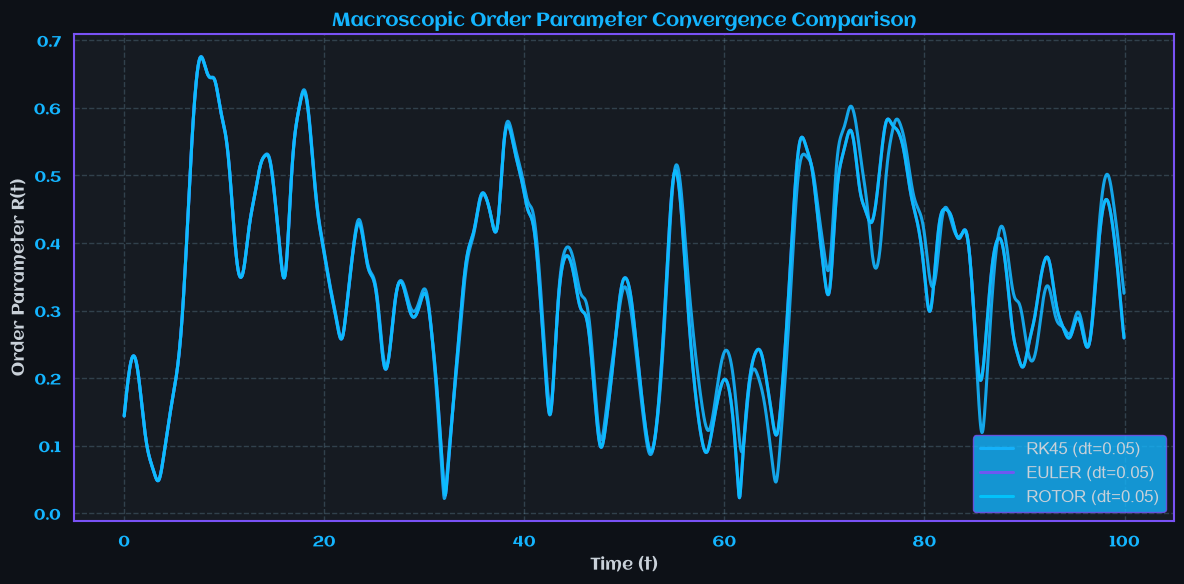

In [13]:
set_style()
fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    'rk45': SCRIBER_PALETTE['accent_cyan'],
    'euler': SCRIBER_PALETTE['accent_purple'],
    'rotor': SCRIBER_PALETTE['accent_teal'],
}

for solver in solvers:
    data_path = f'data/benchmark/{solver}.npz'
    if os.path.exists(data_path):
        data = np.load(data_path)
        phases = data['theta']    # (T, N) phase array
        r = compute_order_parameter(phases)    # (T,) order parameter array
        t = np.arange(phases.shape[0]) * base_config['dt']

        ax.plot(
            t,
            r,
            label=f"{solver.upper()} (dt={base_config['dt']})",
            color=colors.get(solver, SCRIBER_PALETTE['accent_cyan']),
            alpha=0.9,
            linewidth=2.2,
        )

ax.set_xlabel('Time (t)', fontsize=12)
ax.set_ylabel('Order Parameter R(t)', fontsize=12)
ax.set_title('Macroscopic Order Parameter Convergence Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', frameon=True, framealpha=0.8)
_apply_aclonica_font(ax)
plt.tight_layout()
plt.show()

## 🩺 4. Diagnosis of Conservation Violations (`energy_conserved`)
Analyze the metadata generated by the framework's symmetry-tracking mode to confirm if energy or global phase invariants drift under fixed-step vs. geometric schemes.

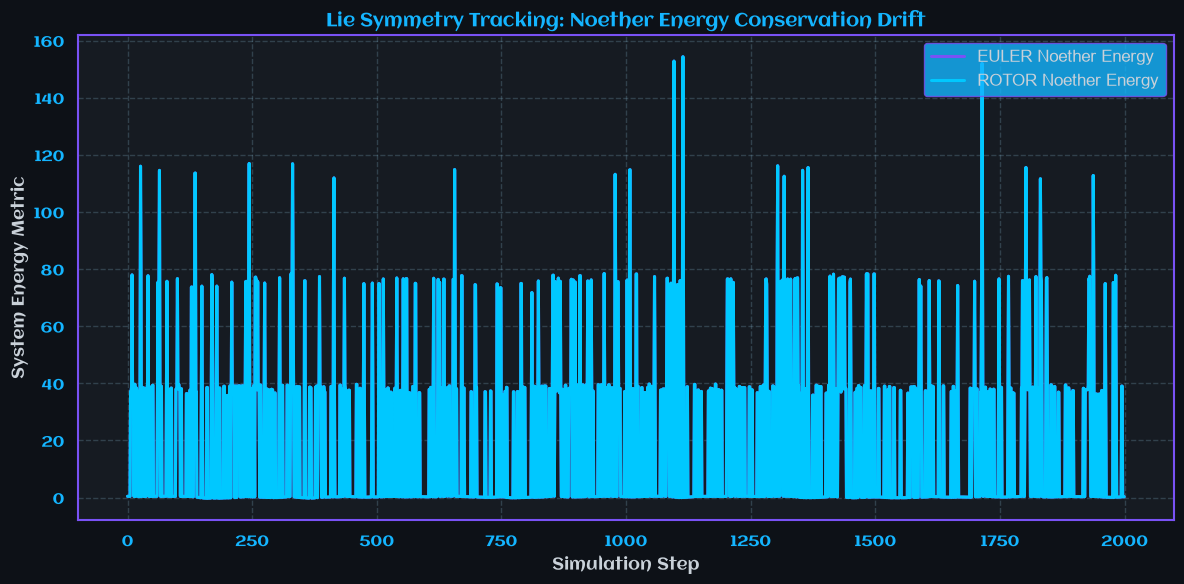

In [14]:
set_style()
fig, ax = plt.subplots(figsize=(12, 6))

for solver in ['euler', 'rotor']:
    data_path = f'data/benchmark/{solver}.npz'
    if os.path.exists(data_path):
        data = np.load(data_path)

        phases = data['theta']
        times = data['time'] if 'time' in data else np.arange(phases.shape[0]) * base_config['dt']
        states = {f"node_{i}": phases[:, i] for i in range(phases.shape[1])}
        metrics = track_lie_symmetries(states, times)
        energy = metrics.energy_conserved
            
        ax.plot(
            energy,
            label=f"{solver.upper()} Noether Energy",
            color=colors.get(solver, SCRIBER_PALETTE['accent_cyan']),
            linewidth=2.2,
        )

ax.set_xlabel('Simulation Step', fontsize=12)
ax.set_ylabel('System Energy Metric', fontsize=12)
ax.set_title('Lie Symmetry Tracking: Noether Energy Conservation Drift', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', frameon=True, framealpha=0.8)
_apply_aclonica_font(ax)
plt.tight_layout()
plt.show()

## 5. 🔢 Multi-Step Convergence Sweep for Vectorized Fast Euler `RotorSolver`
Demonstrate convergence of the fast Euler integration rotor solver directly using `RotorSolver` API and CLI sweeps by decaying $dt$ down to the stability threshold.

🧪 Testing sweep configuration with dt=0.05...
🧪 Testing sweep configuration with dt=0.01...
🧪 Testing sweep configuration with dt=0.002...


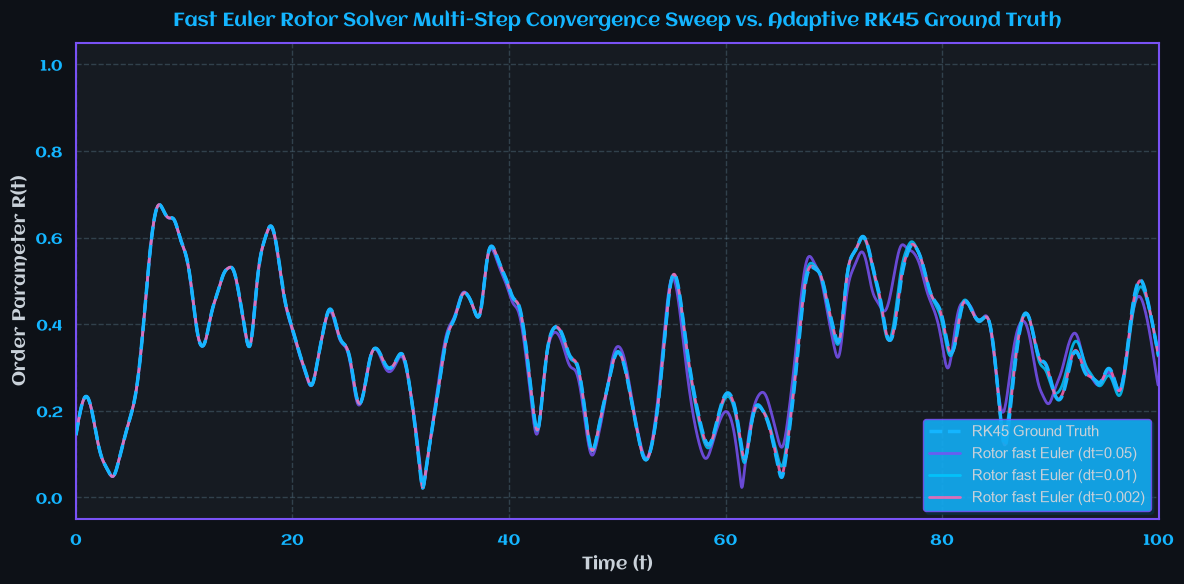

In [15]:
dt_steps = [0.05, 0.01, 0.002]
set_style()
fig, ax = plt.subplots(figsize=(12, 6))

# 📈 Replot RK45 Ground Truth
rk45_data = np.load('data/benchmark/rk45.npz')
phases_rk45 = rk45_data['theta']    # (T, N) phase array
r_rk45 = compute_order_parameter(phases_rk45)   # (T,) order parameter array

# Compute dt from the time array
dt_rk45 = float(rk45_data['time'][1] - rk45_data['time'][0]) if 'time' in rk45_data else base_config['dt']
t_rk45 = np.arange(phases_rk45.shape[0]) * dt_rk45
ax.plot(t_rk45, r_rk45, '--', color=SCRIBER_PALETTE['accent_cyan'], label='RK45 Ground Truth', linewidth=2.5, zorder=5)

# 🧹 Sweep through time steps for the Rotor Solver (using fast Euler evolution)
sweep_palette = [SCRIBER_PALETTE['accent_purple'], SCRIBER_PALETTE['accent_teal'], '#FF66B3']

for idx, test_dt in enumerate(dt_steps):
    print(f"🧪 Testing sweep configuration with dt={test_dt}...")
    output_path = f'data/benchmark/rotor_dt_{test_dt}.npz'

    # Run generation if not already present or refresh dataset
    sweep_config = base_config.copy()
    sweep_config['dt'] = test_dt
    sweep_config['timesteps'] = int(base_config['timesteps'] * (base_config['dt'] / test_dt))

    with open('data/benchmark/sweep_config.json', 'w') as f:
        json.dump(sweep_config, f, indent=2)

    cmd = [
        'kuramoto', 'generate',
        '--config', 'data/benchmark/sweep_config.json',
        '--solver', 'rotor',
        '-o', output_path
    ]
    subprocess.run(cmd, check=True)

    # 📈 Parse and plot sweep results
    sweep_data = np.load(output_path)
    phases_sweep = sweep_data['theta']
    t_sweep = np.arange(phases_sweep.shape[0]) * test_dt
    r_sweep = compute_order_parameter(phases_sweep)

    ax.plot(
        t_sweep,
        r_sweep,
        label=f"Rotor fast Euler (dt={test_dt})",
        color=sweep_palette[idx % len(sweep_palette)],
        alpha=0.85,
        linewidth=2.0,
    )

ax.set_xlabel('Time (t)', fontsize=13, fontweight='semibold')
ax.set_ylabel('Order Parameter R(t)', fontsize=13, fontweight='semibold')
ax.set_title('Fast Euler Rotor Solver Multi-Step Convergence Sweep vs. Adaptive RK45 Ground Truth', fontsize=14, fontweight='bold', pad=12)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0, t_rk45[-1])
ax.legend(loc='lower right', frameon=True, framealpha=0.85, shadow=True, fontsize=11)
_apply_aclonica_font(ax)
plt.tight_layout()
plt.show()